In [ ]:
import warnings
warnings.filterwarnings("ignore")


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import math

from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split

from statsmodels.stats.diagnostic import linear_reset
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV, StratifiedKFold, ParameterGrid, KFold
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.manifold import TSNE

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/credit_risk_dataset.csv')
df=data
data.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


В нашем случае, человек, у которого случится дефолт будет обозначаться 1 в loan_status, соотвественно 0, если дефолта у нег не случится.

In [ ]:
home_ownership = np.unique(data['person_home_ownership'].to_numpy())
home_ownership

array(['MORTGAGE', 'OTHER', 'OWN', 'RENT'], dtype=object)

In [ ]:
loan_intent = np.unique(data['loan_intent'].to_numpy())
loan_intent

array(['DEBTCONSOLIDATION', 'EDUCATION', 'HOMEIMPROVEMENT', 'MEDICAL',
       'PERSONAL', 'VENTURE'], dtype=object)

Понятное дело, что для этих признаков буудем использовать Dummy-переменные

Посмотрим теперь более подробное описание нашего датасета





In [ ]:
data.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


Видим очевидный выброс -- 144 года человеку! давайте выбросим все данные, где людям >120 лет.

In [ ]:
data = data[data['person_age'] <=120]
data.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32576.000000,3.257600e+04,31681.000000,32576.000000,29461.000000,32576.000000,32576.000000,32576.000000
mean,27.718044,6.588214e+04,4.789527,9589.117755,11.011547,0.218197,0.170212,5.803966
std,6.204990,5.253499e+04,4.142706,6321.886846,3.240623,0.413029,0.106778,4.053791
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,94.000000,2.039784e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


Еще и у нас есть человек, у которого person_emp_length = 123, то есть он работает дольше, чем живет. Исправим наши данные, введя условие, что человек не может работать больше, чем (person_age - 10)





In [ ]:
data = data[data['person_age'] >= data['person_emp_length'] + 10]
data.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,31679.000000,3.167900e+04,31679.000000,31679.000000,28632.000000,31679.000000,31679.000000,31679.000000
mean,27.730673,6.649010e+04,4.782064,9659.962436,11.039701,0.215442,0.169610,5.809211
std,6.213427,5.276879e+04,4.034948,6334.360554,3.229409,0.411135,0.106269,4.059710
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.936600e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.600000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,8.000000e+04,7.000000,12500.000000,13.480000,0.000000,0.230000,8.000000
max,94.000000,2.039784e+06,41.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


Реализуем теперь dummy для категориальных признаков.

In [ ]:
encoder = OneHotEncoder(drop='first', sparse_output=False)
data = data.reset_index(drop=True)
data_enc = encoder.fit_transform(data[['person_home_ownership', 'loan_intent']])

encoded_df = pd.DataFrame(data_enc,
                          columns=encoder.get_feature_names_out(['person_home_ownership', 'loan_intent']))

data = data.drop('person_home_ownership', axis =1)
data = data.drop('loan_intent', axis =1)

data = pd.concat([data, encoded_df], axis=1)


In [ ]:
data

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,21,9600,5.0,B,1000,11.14,0,0.10,N,2,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1,25,9600,1.0,C,5500,12.87,1,0.57,N,3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,23,65500,4.0,C,35000,15.23,1,0.53,N,2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,24,54400,8.0,C,35000,14.27,1,0.55,Y,4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,21,9900,2.0,A,2500,7.14,1,0.25,N,2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31674,57,53000,1.0,C,5800,13.16,0,0.11,N,30,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
31675,54,120000,4.0,A,17625,7.49,0,0.15,N,19,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
31676,65,76000,3.0,B,35000,10.99,1,0.46,N,28,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
31677,56,150000,5.0,B,15000,11.48,0,0.10,N,26,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


С loan_grade ситуация интереснее -- в данной ситуации порядок имеет смысл. A -- это хороший заемщик, а G -- плохой. Заменим соотвествующие буквы на числа от 1 до 7 по порядку.

In [ ]:
loan_grade = np.unique(data['loan_grade'].to_numpy())
loan_grade

array(['A', 'B', 'C', 'D', 'E', 'F', 'G'], dtype=object)

In [ ]:
data['loan_grade'][data['loan_grade'] == 'A'] = 1

In [ ]:
data['loan_grade'][data['loan_grade'] == 'B'] = 2
data['loan_grade'][data['loan_grade'] == 'C'] = 3
data['loan_grade'][data['loan_grade'] == 'D'] = 4
data['loan_grade'][data['loan_grade'] == 'E'] = 5
data['loan_grade'][data['loan_grade'] == 'F'] = 6
data['loan_grade'][data['loan_grade'] == 'G'] = 7

In [ ]:
data['cb_person_default_on_file'][data['cb_person_default_on_file'] == 'Y'] = 1
data['cb_person_default_on_file'][data['cb_person_default_on_file'] == 'N'] = 0
data['cb_person_default_on_file'].astype(int)
data['loan_grade'].astype(int)

,loan_grade
0,2
1,3
2,3
3,3
4,1
...,...
31674,3
31675,1
31676,2
31677,2


In [ ]:
data.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
count,31679.000000,3.167900e+04,31679.000000,31679.000000,28632.000000,31679.000000,31679.000000,31679.000000,31679.000000,31679.000000,31679.000000,31679.000000,31679.000000,31679.000000,31679.000000,31679.000000
mean,27.730673,6.649010e+04,4.782064,9659.962436,11.039701,0.215442,0.169610,5.809211,0.003378,0.076076,0.507339,0.198491,0.110799,0.186149,0.169418,0.175290
std,6.213427,5.276879e+04,4.034948,6334.360554,3.229409,0.411135,0.106269,4.059710,0.058020,0.265123,0.499954,0.398870,0.313888,0.389233,0.375127,0.380221
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,3.936600e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,26.000000,5.600000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,30.000000,8.000000e+04,7.000000,12500.000000,13.480000,0.000000,0.230000,8.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,94.000000,2.039784e+06,41.000000,35000.000000,23.220000,1.000000,0.830000,30.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


На текущий момент я уже вижу дисбаланс классов, а именно -- только 21% людей по итогу вернул долг. Поэтому качество модели будем оценивать по ROC-AUC метрике, так как она устройчива к дисбалансу классов.

Но перед этим посмотрим на матрицу корреляций признаков и целевой переменной.



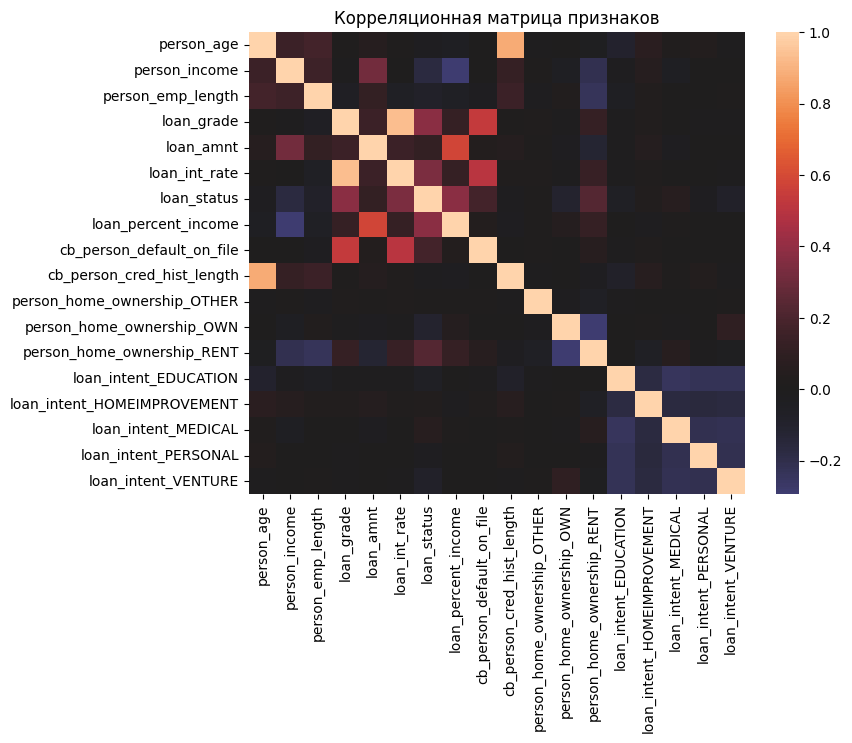

In [ ]:
corr_matrix = data.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(corr_matrix, center=0, annot=False, fmt='.2f')
plt.title('Корреляционная матрица признаков')
plt.show()

Наблюдается очень сильная корреляция между возрастом человека и длиной его кредитной истории, что логично.

loan_grade и loan_int_rate тоже сильно коррелируют

Для всех сильно коррелирующих признаков применим Variance Inflation Factor, который показывает  насколько сильно мультиколлинеарность увеличивает дисперсию оценки коэффициента регрессии.



In [ ]:
data = data.replace([np.inf, -np.inf], np.nan)

data = data.dropna()

In [ ]:
vif_data = pd.DataFrame()
vif_data['feature'] = data.columns
vif_data['VIF'] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]
print(vif_data.sort_values('VIF', ascending=False))

                        feature        VIF
5                 loan_int_rate  75.351144
0                    person_age  44.188647
3                    loan_grade  34.385255
7           loan_percent_income   9.915190
4                     loan_amnt   9.021425
9    cb_person_cred_hist_length   8.838709
1                 person_income   4.857501
2             person_emp_length   2.655300
12   person_home_ownership_RENT   2.621987
13        loan_intent_EDUCATION   2.162308
15          loan_intent_MEDICAL   2.097182
17          loan_intent_VENTURE   2.067927
16         loan_intent_PERSONAL   2.015998
6                   loan_status   1.883365
8     cb_person_default_on_file   1.704118
14  loan_intent_HOMEIMPROVEMENT   1.687132
11    person_home_ownership_OWN   1.249479
10  person_home_ownership_OTHER   1.010569


У этого показатеоя идеальное значение -- 1, а у нас есть признак, который показывает 75, это свидетельствует о бешенной мультиколлинеарности. Выкинем этот признак.

In [ ]:
data = data.drop('loan_int_rate', axis = 1)


In [ ]:
vif_data = pd.DataFrame()
vif_data['feature'] = data.columns
vif_data['VIF'] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]
print(vif_data.sort_values('VIF', ascending=False))

                        feature        VIF
0                    person_age  29.678755
6           loan_percent_income   9.769939
4                     loan_amnt   9.010705
8    cb_person_cred_hist_length   7.570001
3                    loan_grade   7.222383
1                 person_income   4.812599
2             person_emp_length   2.652454
11   person_home_ownership_RENT   2.562006
12        loan_intent_EDUCATION   2.127204
14          loan_intent_MEDICAL   2.072313
16          loan_intent_VENTURE   2.045224
15         loan_intent_PERSONAL   1.993293
5                   loan_status   1.866990
7     cb_person_default_on_file   1.701499
13  loan_intent_HOMEIMPROVEMENT   1.678733
10    person_home_ownership_OWN   1.246107
9   person_home_ownership_OTHER   1.010070


В целом, все еще есть признак с большим VIF, но уже куда ни шло.

Посмотрим на гистограммы некоторых числовых признаков.

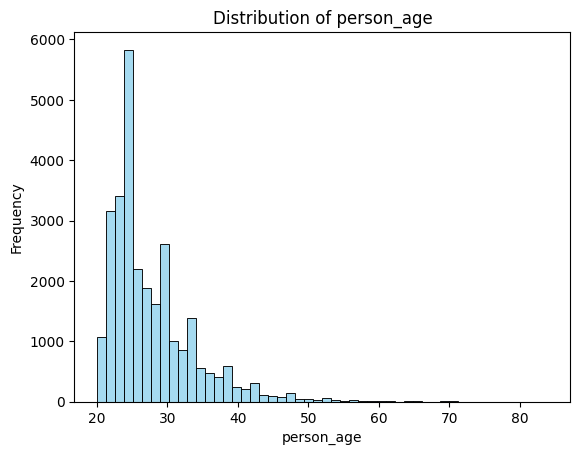

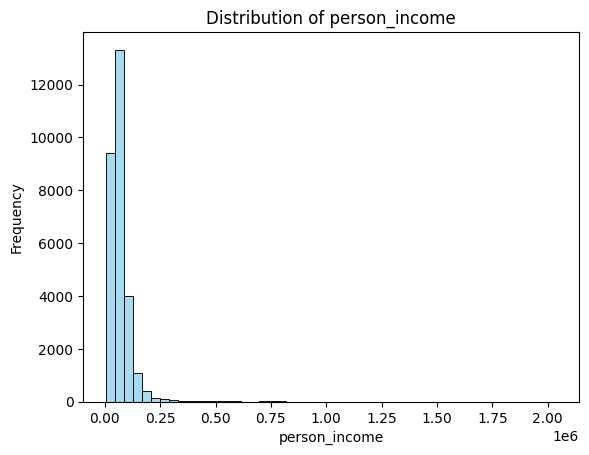

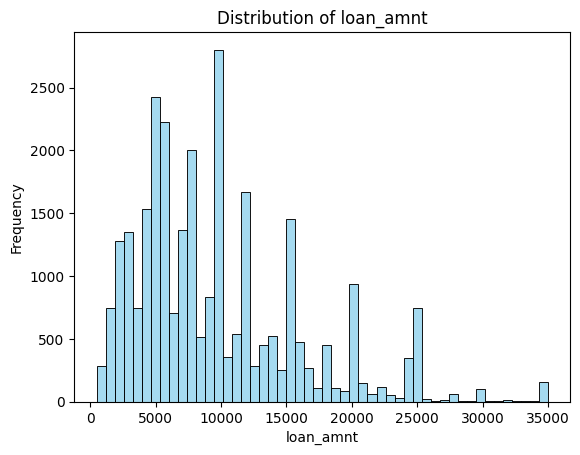

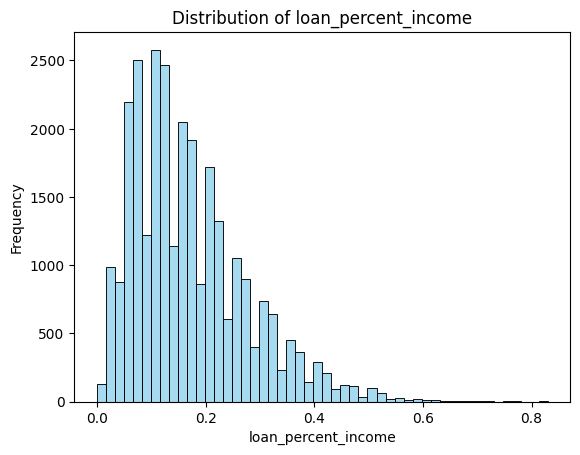

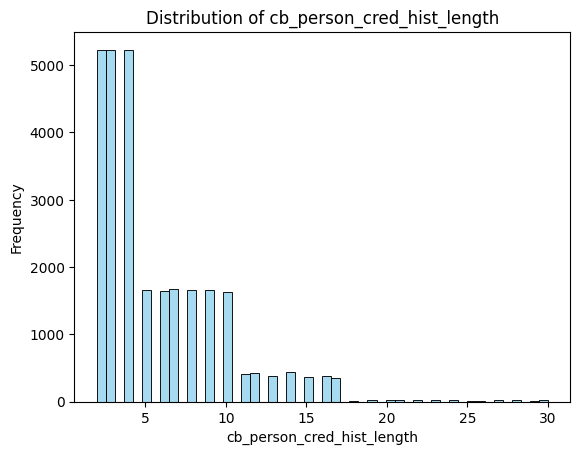

In [ ]:
numeric_cols = ['person_age', 'person_income', 'loan_amnt',
                'loan_percent_income', 'cb_person_cred_hist_length']

for col in numeric_cols:
    plt.figure()
    sns.histplot(data[col], bins=50, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

Распределение возраста и зарплаты человека напоминает лог-нормальное распределение. У размера займа каких-то содержательных закономерносей не выявить, кроме тех, что люди стараются брать в долг округленную сумму. Для отношения размера планируемого займа к зарплате тоже можно сделать предположение о логнормальности распределения, только с меньшим sigma, а именно -- на уровне $\sigma =\frac12$.

Оценим также насколько часто встречаются некоторые категориальные признаки.

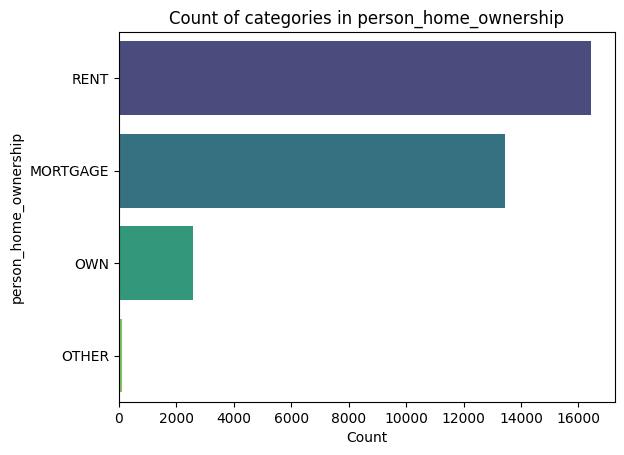

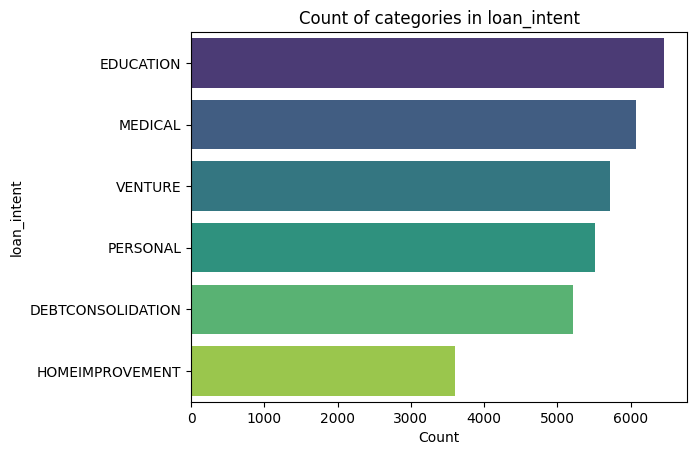

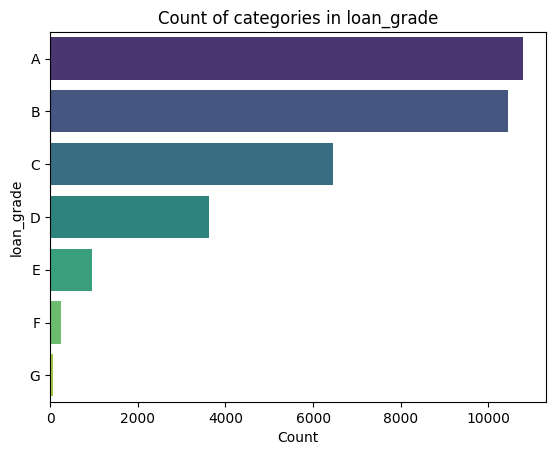

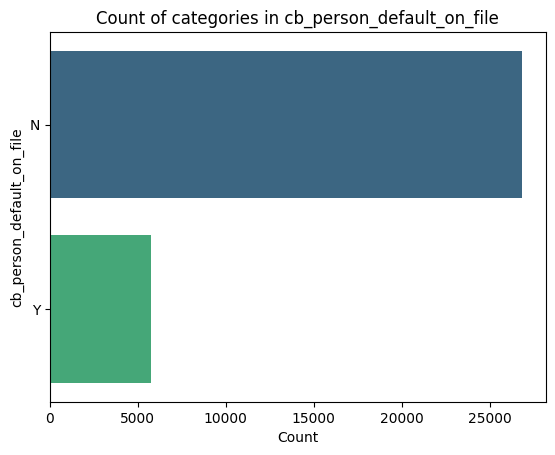

In [ ]:
categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

for col in categorical_cols:
    plt.figure()
    sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')
    plt.title(f'Count of categories in {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.show()

Видим, например, что классы E, F, G -- очень малочисленные, сравнительно с другими. Возможно это связано с тем, что люди, у которых случается дефолт уже имеют низкий грейд и они не идут за займом, что отлично согласуется с тем, что в countplot для cb_person_default_on_file количество людей, у которых уже был дефолт сильно меньше, чем тех, у которого его пока не было.

А теперь посмотрим как связаны те же числовые признаки, только с условием того случится ли у человека дефолт.

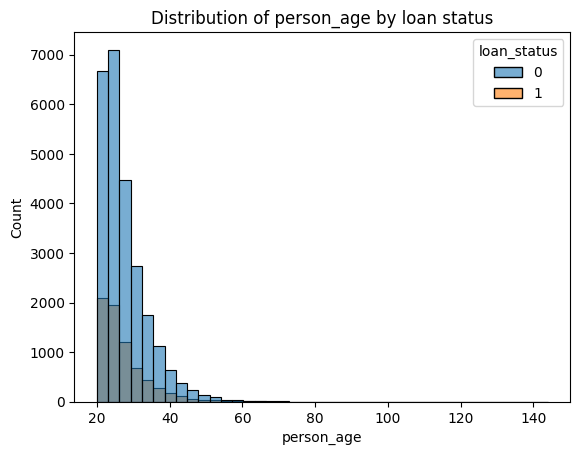

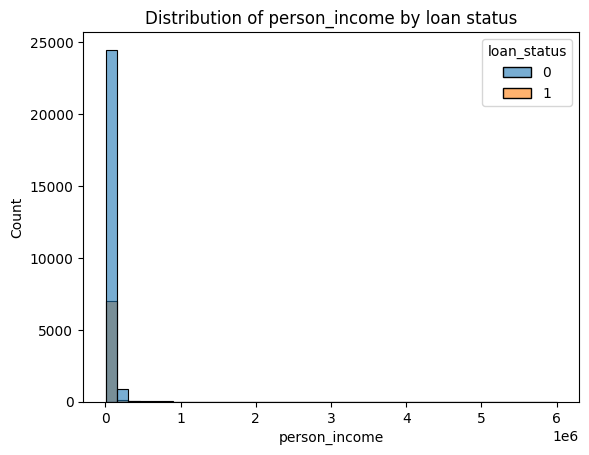

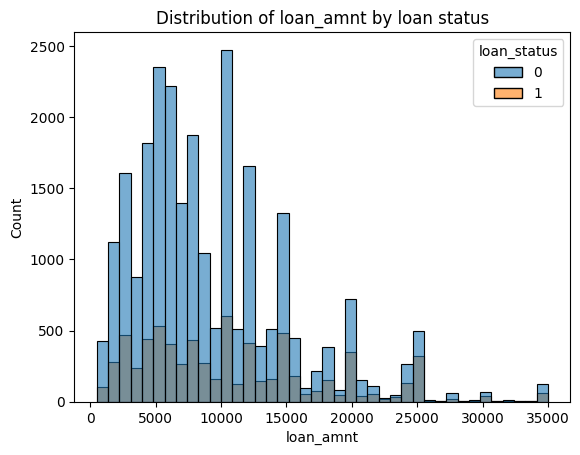

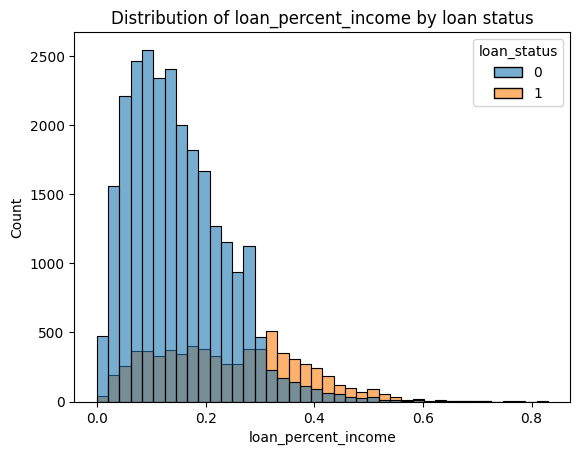

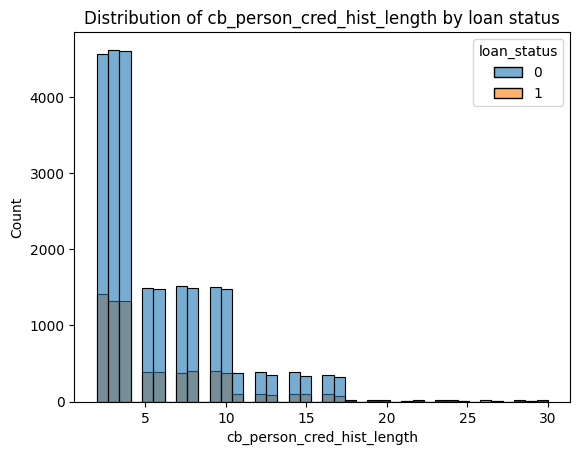

In [ ]:
for col in numeric_cols:
    plt.figure()
    sns.histplot(data=df, x=col, hue='loan_status', bins=40, alpha=0.6)
    plt.title(f'Distribution of {col} by loan status')
    plt.show()

Мы видим для всех перечисленных признаков примерно одинаковые распределения для обоих классов, но не для loan_percent_income. Становится понятно, что если человек берет займ, размер которого больше чем ~30% от его зарплаты, то он скорее всего дефолтнется. Это наталкивает нас на мысль, что это очень важный признак, на основе которого можно строить пресдказательную модель.

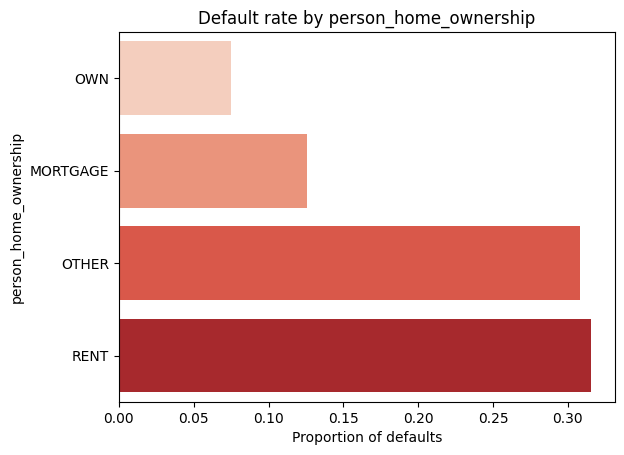

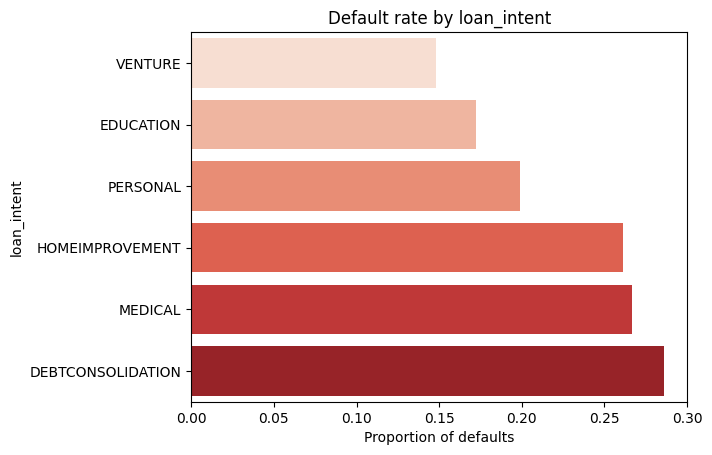

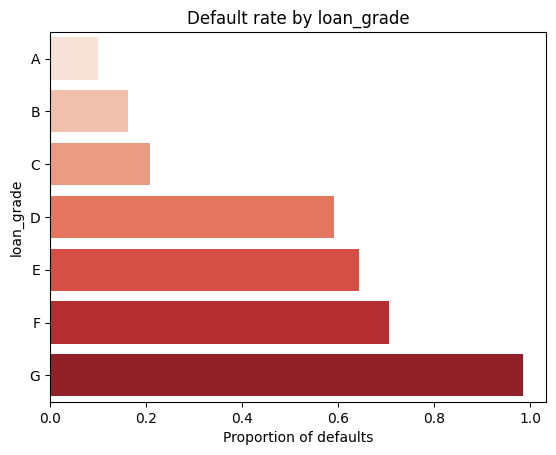

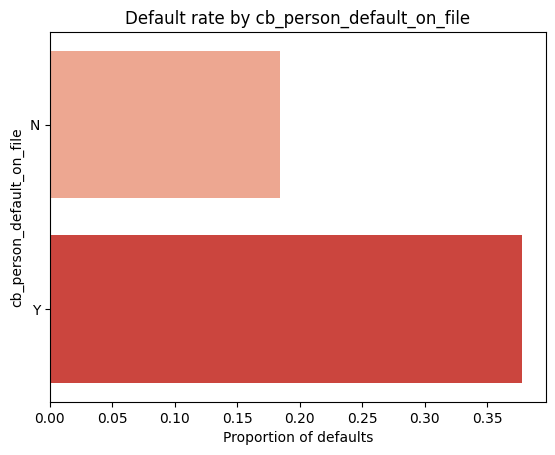

In [ ]:
for col in categorical_cols:
    plt.figure()
    default_rate = df.groupby(col)['loan_status'].mean().sort_values()
    sns.barplot(x=default_rate.values, y=default_rate.index, palette='Reds')
    plt.title(f'Default rate by {col}')
    plt.xlabel('Proportion of defaults')
    plt.ylabel(col)
    plt.show()

Отсюда уже понятно, что люди с низким грейдом, то есть grade = G вообще не возвращают кредиты особенно. Также, по назначению кредита, самым рскованным оказался кредит на покрытие других кредитов, что тоже неудивительно.

In [ ]:
# По prev_default
stat_by_prev = data.groupby('prev_default').agg(
    n=('loan_status', 'size'),
    default_rate=('loan_status', 'mean'),
    mean_age=('person_age', 'mean'),
    mean_income=('person_income', 'mean'),
    mean_grade=('grade_ord', 'mean'),
    mean_lpi=('loan_percent_income', 'mean'),
).round(3)
stat_by_prev.index = stat_by_prev.index.map({0: 'no prior default', 1: 'prior default'})
print('Описательные статистики по cb_person_default_on_file:')
stat_by_prev

Полезным также бывает строить bivariate plot, который позволяет углядеть некоторые нелинейные закономерности в данных.

KeyError: 'log_income'

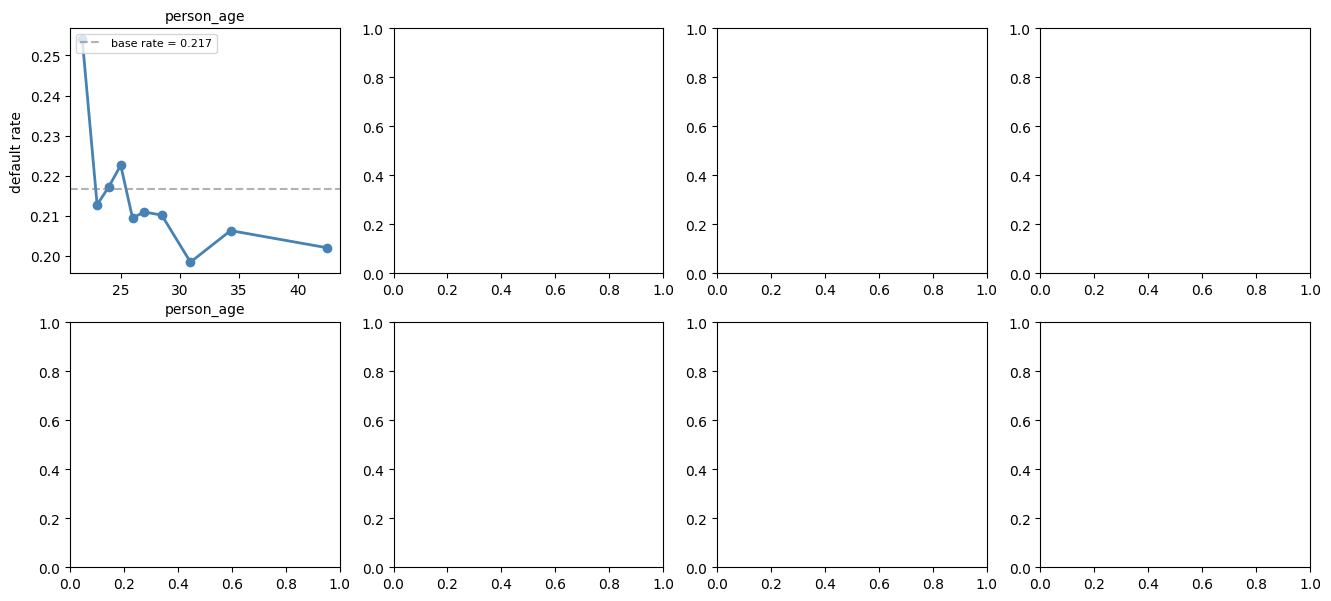

In [ ]:
def bivariate_plot(ax, df, xcol, n_bins=10, title=None):
    df = df.copy()
    df['_bin'] = pd.qcut(df[xcol], q=n_bins, duplicates='drop')
    grouped = df.groupby('_bin', observed=True).agg(
        x=(xcol, 'mean'),
        y=('loan_status', 'mean'),
        n=('loan_status', 'size')
    ).reset_index(drop=True)
    ax.plot(grouped['x'], grouped['y'], 'o-', color='steelblue', linewidth=2, markersize=6)
    ax.axhline(df['loan_status'].mean(), ls='--', color='gray', alpha=0.6,
               label=f"base rate = {df['loan_status'].mean():.3f}")
    ax.set_title(title or xcol, fontsize=10)
    ax.set_xlabel(xcol)
    ax.set_ylabel('default rate')
    ax.legend(fontsize=8, loc='upper left')
    return grouped

cont_to_plot = ['person_age', 'log_income', 'person_emp_length',
                'loan_amnt', 'loan_percent_income', 'loan_int_rate',
                'cb_person_cred_hist_length', 'grade_ord']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, cont_to_plot):
    bivariate_plot(ax, data, col, n_bins=10)
fig.suptitle('Эмпирическая default rate в децилях каждого предиктора',
             y=1.02, fontsize=12)
fig.tight_layout()
plt.show()

Попробуем также выполнить метод главных компонент.

In [ ]:
y = data['loan_status'].to_numpy()
X = data.drop(columns=['loan_status']).astype(float).to_numpy()
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size =0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_train)
X_te_s = scaler.transform(X_test)

In [ ]:
pca = PCA()
pca.fit(X_tr_s)

# Смотрим объяснённую дисперсию
explained_variance_ratio = pca.explained_variance_ratio_
cumsum = np.cumsum(explained_variance_ratio)

print("Доля дисперсии на каждой компоненте:", explained_variance_ratio)
print("Накопленная доля дисперсии:", cumsum)

In [ ]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_)
plt.xlabel('Номер главной компоненты')
plt.ylabel('Доля объяснённой дисперсии')
plt.title('Scree plot')

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumsum)+1), cumsum, 'ro-')
plt.xlabel('Число компонент')
plt.ylabel('Накопленная дисперсия')
plt.title('Кумулятивная дисперсия')
plt.axhline(y=0.95, color='k', linestyle='--', label='95% дисперсии')
plt.legend()
plt.tight_layout()
plt.show()

В нашем случае, дисперсия убывает плавно, поэтому какие-то конкоектные признаки брать смысла не имеет. Пользуемся тем, что есть.